In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/preparation-fro-bd-ml-2026/sample_test.csv
/kaggle/input/preparation-fro-bd-ml-2026/train.csv
/kaggle/input/preparation-fro-bd-ml-2026/baseline/fit.ipynb
/kaggle/input/preparation-fro-bd-ml-2026/baseline/Dockerfile
/kaggle/input/preparation-fro-bd-ml-2026/baseline/requirements.txt
/kaggle/input/preparation-fro-bd-ml-2026/baseline/predict.ipynb
/kaggle/input/preparation-fro-bd-ml-2026/baseline/predict.py
/kaggle/input/preparation-fro-bd-ml-2026/baseline/run.sh
/kaggle/input/models-nto2025/ManyModels.pkl
/kaggle/input/models-nto2025/lightBoobsUWF.pkl
/kaggle/input/models-nto2025/catboobs_shrink.pkl
/kaggle/input/models-nto2025/best_cols_LGBM.pkl
/kaggle/input/models-nto2025/LGBM_rubert_turbo.pkl
/kaggle/input/models-nto2025/catboobs.pkl
/kaggle/input/models-nto2025/ligthboobs.pkl
/kaggle/input/models-nto2025/lgboobs.pkl
/kaggle/input/models-nto2025/pdd.pkl
/kaggle/input/models-nto2025/uwuf.pkl
/kaggle/input/clip-embeddings/test_txt_embs.npy
/kaggle/input/clip-embeddings/img

In [2]:
from transformers import CLIPModel, CLIPProcessor 
from sklearn.metrics import mean_absolute_error 
from catboost import Pool, CatBoostRegressor
import lightgbm as lgb 
from PIL import Image 
import base64  
from io import BytesIO 
import seaborn as sns 
import matplotlib.pyplot as plt 
import pandas as pd 
import polars as pl 
import numpy as np 
import re 
import gc 
import cv2
import torch 
from tqdm.auto import trange, tqdm 
from sklearn.decomposition import PCA 
import os 
import random
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold 

2026-01-14 16:25:53.197652: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768407953.398507      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768407953.454300      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768407953.899572      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768407953.899617      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768407953.899620      55 computation_placer.cc:177] computation placer alr

In [3]:
class Cfg: 
    DEVICE = torch.device('cuda' if torch.cuda.is_available else 'cpu')
    EMBEDDER = 'openai/clip-vit-base-patch16'
    CAT = {
        'learning_rate': 0.05, 
        'depth': 5, 
        'loss_function': 'RMSE', 
        'eval_metric': 'RMSE', 
        'use_best_model': True, 
        'iterations': 1000,
        'task_type': 'GPU'
    }
    LGB = {
        'n_estimators': 1000,
        'learning_rate': 0.05,
        'num_leaves': 32,
        'max_depth': 5,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.3,
        'verbose': -1
    }  
    RND = 42
    NEPOCHS = 2
    NFOLDS = 3

In [4]:
def fix(seed): 
    torch.cuda.manual_seed(seed)
    torch.manual_seed(seed) 
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed) 
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

fix(Cfg.RND)

In [5]:
train = pd.read_csv('/kaggle/input/preparation-fro-bd-ml-2026/train.csv') 
test = pd.read_csv('/kaggle/input/preparation-fro-bd-ml-2026/sample_test.csv')

In [6]:
train.head()

,view,like,comment,hide,expand,open_photo,open,share_to_message,text,photo
0,2694,175,2,2,2,151,73,6,Чудесного всем утра&#33;<br><br>#ShuiLongYin #...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...
1,21688,58,2,8,944,1595,1102,51,&#127802; ЦВЕТЫ ПРОТИВ ВРЕДИТЕЛЕЙ: КРАСОТА С П...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...
2,93784,1225,14,34,86,6370,4755,457,"Моя волшебная коробочка, которая помогает заня...",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...
3,15430,68,11,0,8,1520,428,25,Состояние дороги в деревню Стешевская (Корбозеро),/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...
4,13578,284,1,30,4,189,28,9,&#128247;aiartistically,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...


In [7]:
train.isna().sum()

view                   0
like                   0
comment                0
hide                   0
expand                 0
open_photo             0
open                   0
share_to_message       0
text                3578
photo                  0
dtype: int64

In [8]:
train['text'] = train['text'].fillna('')
test['text'] = test['text'].fillna('')

In [9]:
target_cols = ['like', 'comment', 'hide', 'expand', 'open_photo', 'open', 'share_to_message'] 

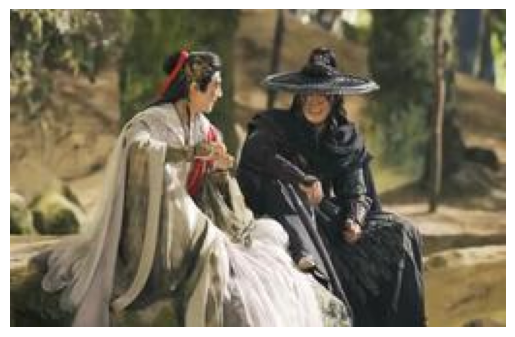

In [9]:
def get_image(image_code): 
    image = Image.open(BytesIO(base64.b64decode(image_code))).convert('RGB')
    return image

example = get_image(train.loc[0, 'photo']) 
plt.imshow(example) 
plt.axis('off')
plt.show()

In [10]:
def count_upper_case_letter(text): 
    count = 0 
    for char in text: 
        if char.isupper(): 
            count+=1 
            
    return count 

def count_latin_letter(text): 
    count = 0 
    for char in text: 
        if char.isalpha() and char.isascii(): 
            count += 1 
    return count

def add_txt_features(data): 
    data['#_cnt'] = data['text'].apply(lambda x: x.count('#'))
    data['@_cnt'] = data['text'].apply(lambda x: x.count('@')) 
    data['latin_cnt'] = data['text'].apply(count_latin_letter) / len(data['text'])
    data['upper_cnt'] = data['text'].apply(count_upper_case_letter) / len(data['text']) 
    data['text_len'] = data['text'].apply(lambda x: len(x)) 
    data['sent_cnt'] = data['text'].apply(lambda x: len(x.split()))

    return data

In [11]:
train = add_txt_features(train) 
test = add_txt_features(test)

In [12]:
texts = '' 
for text in train['text'].loc[:4]:
    texts += text 

texts

'Чудесного всем утра&#33;<br><br>#ShuiLongYin #WaterDragonsChant #LuoYunxi #XiaoShunyao&#127802; ЦВЕТЫ ПРОТИВ ВРЕДИТЕЛЕЙ: КРАСОТА С ПОЛЬЗОЙ &#127802;<br><br>Цветы – это прелестно&#33; Мы сажаем их для души, чтобы все лето радоваться разноцветью, вдыхать приятные ароматы и наслаждаться красотой и гармонией, что есть в каждом цветке. Но дачник – человек практичный, ему желательно от каждого растения в огороде получить максимум пользы.<br><br>А что могут дать «нежные создания», кроме эстетического удовольствия? Есть ли в них практическая необходимость? Как известно, самая значимая функция цветов — привлечение на участок насекомых-опылителей, но некоторые из них способны и отпугнуть нежелательных гостей – вредителей и болезнетворные микроорганизмы.<br><br>&#127802; Бархатцы (тагетес) против вредителей<br><br>Очень популярное среди садоводов растение – и цветет долго, и особенного ухода не требует. А между тем цветы бархатцев выделяют фитонциды, отпугивающие нематод и других мелких почвенны

In [12]:
def clear_text(text): 
    text = text.strip().lower() 
    text = re.sub(r'(&#\d+;)|(<br\s*/?>)|(\\xa[0-9a-fA-F_]+)|(\\xa0_+)|(\xa0_________________\xa0)|([;,[]]+)|(#[A-Za-z0-9-]+)', '', text)
    return text

In [13]:
train['text'] = train['text'].apply(clear_text)
test['text'] = test['text'].apply(clear_text)

In [14]:
train.head()

,view,like,comment,hide,expand,open_photo,open,share_to_message,text,photo,#_cnt,@_cnt,latin_cnt,upper_cnt,text_len,sent_cnt
0,2694,175,2,2,2,151,73,6,чудесного всем утра,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,5,0,0.00255,0.00055,86,6
1,21688,58,2,8,944,1595,1102,51,цветы против вредителей: красота с пользой цв...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,11,0,0.00700,0.00540,7414,962
2,93784,1225,14,34,86,6370,4755,457,"моя волшебная коробочка, которая помогает заня...",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,2,0,0.00000,0.00005,94,10
3,15430,68,11,0,8,1520,428,25,состояние дороги в деревню стешевская (корбозеро),/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,0,0,0.00000,0.00015,49,6
4,13578,284,1,30,4,189,28,9,aiartistically,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,1,0,0.00070,0.00000,23,1


### Extract image and text embeddings 

In [16]:
embedder = CLIPModel.from_pretrained(Cfg.EMBEDDER).to(Cfg.DEVICE)
processor = CLIPProcessor.from_pretrained(Cfg.EMBEDDER)
embedder.eval()

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

Cancellation requested; stopping current tasks.


KeyboardInterrupt: 

In [19]:
@torch.no_grad() 
def add_txt_emb(text): 
    inputs = processor(
        text=[text], 
        truncation=True, 
        padding=True, 
        return_tensors='pt'
    )
    inputs = {k: v.to(Cfg.DEVICE) for k, v in inputs.items()}
    
    output = embedder.get_text_features(**inputs)
    emb = output / output.norm(dim=-1, keepdim=True)
    
    return emb.cpu().numpy().squeeze() 

@torch.no_grad() 
def add_img_emb(img): 
    inputs = processor(
        images=[img], 
        return_tensors='pt'
    )
    inputs = {k: v.to(Cfg.DEVICE) for k, v in inputs.items()}
    
    output = embedder.get_image_features(**inputs)
    emb = output / output.norm(dim=-1, keepdim=True) 

    return emb.cpu().numpy().squeeze()

In [41]:
txt_embs = [] 
for txt in tqdm(train['text']):
    if not txt: continue
    emb = add_txt_emb(txt) 
    txt_embs.append(emb)

txt_embs = np.vstack(txt_embs)

  0%|          | 0/20000 [00:00<?, ?it/s]

In [52]:
img_embs = [] 
for img in tqdm(train['photo']): 
    img = get_image(img) 
    emb = add_img_emb(img) 
    img_embs.append(emb) 

img_embs = np.vstack(img_embs) 

  0%|          | 0/20000 [00:00<?, ?it/s]

In [57]:
test_txt_embs = []
for txt in tqdm(test['text']): 
    if not txt: continue
    emb = add_txt_emb(txt) 
    test_txt_embs.append(emb) 

test_txt_embs = np.vstack(test_txt_embs)

  0%|          | 0/3526 [00:00<?, ?it/s]

In [70]:
test_img_embs = [] 
for img in tqdm(test['photo']): 
    img = get_image(img) 
    emb = add_img_emb(img) 
    test_img_embs.append(emb) 

test_img_embs = np.vstack(test_img_embs)

  0%|          | 0/3526 [00:00<?, ?it/s]

In [73]:
np.save('txt_embs.npy', txt_embs)
np.save('img_embs.npy', img_embs) 
np.save('test_txt_embs.npy', test_txt_embs)
np.save('test_img_embs.npy', test_img_embs)

In [15]:
txt_embs_ = np.load('/kaggle/input/clip-embeddings/txt_embs.npy')
img_embs_ = np.load('/kaggle/input/clip-embeddings/img_embs.npy')
test_txt_embs_ = np.load('/kaggle/input/clip-embeddings/test_txt_embs.npy')
test_img_embs_ = np.load('/kaggle/input/clip-embeddings/test_img_embs.npy')

In [16]:
img_pca = PCA(n_components=64) 
txt_pca = PCA(n_components=64) 

img_embs = img_pca.fit_transform(img_embs_) 
txt_embs = txt_pca.fit_transform(txt_embs_) 
test_img_embs = img_pca.transform(test_img_embs_)
test_txt_embs = txt_pca.transform(test_txt_embs_)

Let's add embeddings through catboost parameter `embedding_features`, so we need to prepare data for it 

In [131]:
len(train) - txt_embs.shape[0]

3833

In [132]:
len(test) - test_txt_embs.shape[0]

711

In [17]:
train['text_embs'] = list(np.concat([txt_embs_, np.zeros((3833, 512))], axis=0).astype('float32'))
train['img_embs'] = list(img_embs_.astype('float32'))
test['text_embs'] = list(np.concat([test_txt_embs_, np.zeros((711, 512))], axis=0).astype('float32'))
test['img_embs'] = list(test_img_embs_.astype('float32'))

In [18]:
train

,view,like,comment,hide,expand,open_photo,open,share_to_message,text,photo,#_cnt,@_cnt,latin_cnt,upper_cnt,text_len,sent_cnt,text_embs,img_embs
0,2694,175,2,2,2,151,73,6,чудесного всем утра,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,5,0,0.00255,0.00055,86,6,"[-0.000559463, -0.04422728, -0.013524687, 0.01...","[0.10600121, -0.01420531, -0.039554976, 0.0033..."
1,21688,58,2,8,944,1595,1102,51,цветы против вредителей: красота с пользой цв...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,11,0,0.00700,0.00540,7414,962,"[0.019677626, -0.06946464, -0.0247634, 0.02466...","[-0.031236108, -0.064508446, 0.006403195, -0.0..."
2,93784,1225,14,34,86,6370,4755,457,"моя волшебная коробочка, которая помогает заня...",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,2,0,0.00000,0.00005,94,10,"[0.018289343, -0.048765797, -0.021551447, 0.00...","[0.022260195, -0.024166984, 0.030267807, 0.065..."
3,15430,68,11,0,8,1520,428,25,состояние дороги в деревню стешевская (корбозеро),/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,0,0,0.00000,0.00015,49,6,"[0.012259694, -0.05565094, -0.015605313, -0.01...","[0.02047021, -0.08299529, -0.020139635, 0.0229..."
4,13578,284,1,30,4,189,28,9,aiartistically,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,1,0,0.00070,0.00000,23,1,"[0.024186034, -0.021617055, 0.026473934, -0.01...","[-0.021330357, -0.038639672, 0.018640809, 0.02..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,16469,235,8,6,41,650,82,207,"травы, которые понижают давление вы навсегда з...",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,4,0,0.00000,0.00015,110,12,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.10698911, 0.016800283, 0.005557738, 0.01160..."
19996,6394,89,0,0,0,72,1,60,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,0,0,0.00000,0.00000,0,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.05169257, 0.023584953, -0.05411393, 0.04659..."
19997,6717,196,0,1,0,133,5,27,лойс если ждёшь,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,1,0,0.00000,0.00005,25,4,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.0066350936, -0.0005022245, -0.020383798, -..."
19998,5501,14,0,0,0,33,1,1,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,0,0,0.00000,0.00000,0,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.1262119, -0.015851706, -0.02649748, 0.07163..."


Base embeddings addition for statistics.

In [19]:
txt_cols = [f'txt_emb_{i}' for i in range(txt_embs.shape[1])]
img_cols = [f'img_emb_{i}' for i in range(img_embs.shape[1])]
test_txt_cols = [f'txt_emb_{i}' for i in range(test_txt_embs.shape[1])] 
test_img_cols = [f'img_emb_{i}' for i in range(test_img_embs.shape[1])] 

txt_df = pd.DataFrame(txt_embs, columns=txt_cols)
img_df = pd.DataFrame(img_embs, columns=img_cols)
test_txt_df = pd.DataFrame(test_txt_embs, columns=test_txt_cols) 
test_img_df = pd.DataFrame(test_img_embs, columns=test_img_cols)

In [20]:
train = pd.concat([train, txt_df, img_df], axis=1)
test = pd.concat([test, test_txt_df, test_img_df], axis=1)

In [21]:
train = train.drop(columns=['photo', 'text'])
test = test.drop(columns=['photo', 'text'])

In [22]:
train = train.fillna(.0) 
test = test.fillna(.0)

In [24]:
def add_emb_corr(data, drop): 
    data['imgXtxt'] = (data[txt_cols].to_numpy() * data[img_cols].to_numpy()).sum(axis=1)
    data['img_mean'] = data[img_cols].mean(axis=1)
    data['txt_mean'] = data[txt_cols].mean(axis=1)
    data['img_std'] = data[img_cols].std(axis=1)
    data['txt_std'] = data[txt_cols].std(axis=1)
    
    if drop=='cat': 
        data = data.drop(columns=(txt_cols+img_cols))
    if drop=='lgb': 
        data = data.drop(columns=['text_embs', 'img_embs'])
    
    return data

In [25]:
cat_train = add_emb_corr(train, drop='cat') 
cat_test = add_emb_corr(test, drop='cat')
lgb_train = add_emb_corr(train, drop='lgb') 
lgb_test = add_emb_corr(test, drop='lgb')

In [27]:
cat_train.head()

,view,like,comment,hide,expand,open_photo,open,share_to_message,#_cnt,@_cnt,...,upper_cnt,text_len,sent_cnt,text_embs,img_embs,imgXtxt,img_mean,txt_mean,img_std,txt_std
0,2694,175,2,2,2,151,73,6,5,0,...,0.00055,86,6,"[-0.000559463, -0.04422728, -0.013524687, 0.01...","[0.10600121, -0.01420531, -0.039554976, 0.0033...",-0.011526,0.002421,0.002487,0.071366,0.032262
1,21688,58,2,8,944,1595,1102,51,11,0,...,0.00540,7414,962,"[0.019677626, -0.06946464, -0.0247634, 0.02466...","[-0.031236108, -0.064508446, 0.006403195, -0.0...",0.019986,-0.017474,-0.007690,0.068733,0.041385
2,93784,1225,14,34,86,6370,4755,457,2,0,...,0.00005,94,10,"[0.018289343, -0.048765797, -0.021551447, 0.00...","[0.022260195, -0.024166984, 0.030267807, 0.065...",-0.006091,0.008172,0.006703,0.065028,0.027791
3,15430,68,11,0,8,1520,428,25,0,0,...,0.00015,49,6,"[0.012259694, -0.05565094, -0.015605313, -0.01...","[0.02047021, -0.08299529, -0.020139635, 0.0229...",-0.003855,-0.002462,0.004427,0.083641,0.035782
4,13578,284,1,30,4,189,28,9,1,0,...,0.00000,23,1,"[0.024186034, -0.021617055, 0.026473934, -0.01...","[-0.021330357, -0.038639672, 0.018640809, 0.02...",-0.052186,-0.007815,0.006724,0.068151,0.069238


### Train ensemble

Let`s use ensemble of lightgbm & catboost with **UWUF** (User Weighted Unified Feedback) and **Per-target feature specialization**.

In [28]:
from sklearn.base import BaseEstimator 

In [30]:
class LGBEnsembleRegressor(BaseEstimator): 
    def __init__(self, lgb_params):
        self.cbm = lgb.LGBMRegressor(**lgb_params)
        
    def fit(self,X,y,X_val,y_val):
        self.cbm.fit(X,y,eval_set=[(X_val,y_val)])
        
    def predict(self,X_test):
        test_pool = lgb.Dataset(X_test)

        cb_preds = self.cbm.predict(X_test)
        return cb_preds

In [31]:
class CATEnsembleRegressor(BaseEstimator):
    def __init__(self,cb_params):
        self.cbm = CatBoostRegressor(**cb_params)
  
    def fit(self,X,y,X_val,y_val,cat_features=None,verbose=False,embedding_features=['text_embs', 'img_embs']):
        train_pool = Pool(X,label=y,cat_features=cat_features,embedding_features=embedding_features)
        eval_pool = Pool(X_val,label=y_val,cat_features=cat_features,embedding_features=embedding_features)
        self.cbm.fit(train_pool,eval_set=eval_pool,verbose=verbose)
      
    def predict(self,X_test,cat_features=None,embedding_features=['text_embs', 'img_embs']):
        test_pool = Pool(X_test,cat_features=cat_features, embedding_features=embedding_features)
        cb_preds = self.cbm.predict(test_pool)
        return cb_preds

In [44]:
class CustomKFold(BaseEstimator): 
    def __init__(self, num_folds, num_epochs, params, score_func=None, random_state=Cfg.RND): 
        self.num_folds = num_folds 
        self.num_epochs = num_epochs 
        self.params = params 
        self.score_func = score_func 
        self.random_state = random_state
        self.models = []

    def fit(self, train, train_cols=None, cat_features=None, embedding_features=None, label_col=None, verbose=False): 
        self.scores = [] 

        board = trange(self.num_epochs)
        for i in board: 
            kfold = KFold(n_splits=self.num_folds, random_state=self.random_state+i, shuffle=True) 
            for fold, (train_index, test_index) in enumerate(kfold.split(train, train[label_col])):
                train_df = train.iloc[train_index]
                test_df = train.iloc[test_index]

                params = self.params 
                params['random_state'] = fold + self.random_state

                if cat_features or embedding_features: 
                    model = CATEnsembleRegressor(params)
                    model.fit(
                        X = train_df[train_cols],
                        y = train_df[label_col] / train_df['view'],
                        X_val = test_df[train_cols],
                        y_val = test_df[label_col] / test_df['view'],
                        cat_features = cat_features,
                        embedding_features=embedding_features,
                        verbose = verbose
                    )
                    
                    cb_preds = model.predict(test_df[train_cols],cat_features,embedding_features)
                    avg_preds = cb_preds 
                    
                else: 
                    model = LGBEnsembleRegressor(params) 
                    model.fit(
                        X = train_df[train_cols],
                        y = train_df[label_col] / train_df['view'],
                        X_val = test_df[train_cols], 
                        y_val = test_df[label_col] / test_df['view'],
                    )
                    lgb_preds = model.predict(test_df[train_cols])
                    avg_preds = lgb_preds 
                
                self.scores += [[
                    self.score_func(
                        test_df[label_col] / test_df['view'],
                        avg_preds
                    )
                ]]
                
                print(*self.scores[-1])
                self.models += [model]
                del model, train_df, test_df

            board.set_postfix(loss=self.scores[-1])
                
        print(f"Total Score {np.mean([x[0] for x in self.scores])}")
        
    def predict(self,test_data,train_cols=None,cat_features=None,embedding_features=None):
        preds = np.mean([
            model.predict(test_data[train_cols],cat_features=cat_features, embedding_features=embedding_features)
            for model in self.models
        ],axis=0)
        return preds
    
    def get_feature_importance(self,type='FeatureImportance'):
        imp_0 = self.models[0].cbm.get_feature_importance(prettified=True,type=type).set_index('Feature Id')
        
        for i in range(1,len(self.models)):
            imp_0 += self.models[i].cbm.get_feature_importance(prettified=True,type=type).set_index('Feature Id')
            
        return (imp_0 / len(self.models)).sort_values(by='Importances')[::-1]

In [33]:
def score_func(true, pred): 
    return mean_squared_error(true, pred)

In [34]:
train_cols = ['view','#_cnt','@_cnt','latin_cnt','upper_cnt','text_len','sent_cnt',
              'text_embs','img_embs','imgXtxt','img_mean','txt_mean','img_std','txt_std']

In [36]:
def pfs(fitted_model, trdata, tedata, label_col): 
    imp = fitted_model.get_feature_importance(prettified=True,type=type).set_index('Feature Id')\
            .sort_values(by='Importances')[::-1]

    features = imp[:128].index.to_list() 

    train = data[features]

    fitted_model.fit(
        X = trdata[features],
        y = trdata[label_col] / trdata['view'],
        X_val = tedata[train_cols],
        y_val = tedata[label_col] / tedata['view'],
        cat_features = cat_features,
        embedding_features=embedding_features,
        verbose = False
    )

    return fitted_model

In [38]:
def train_catboost(target_cols): 
    models = {}
    kfoldmodel = CustomKFold(Cfg.NFOLDS, Cfg.NEPOCHS, Cfg.CAT, score_func)

    gc.collect()
    for target in target_cols: 
        kfoldmodel.fit(cat_train, train_cols=train_cols, cat_features=None, embedding_features=['text_embs', 'img_embs'], label_col=target)
        models[target] = [m.cbm for m in kfoldmodel.models]

    return models

In [39]:
def train_lightgbm(target_cols): 
    models = {}
    kfoldmodel = CustomKFold(Cfg.NFOLDS, Cfg.NEPOCHS, Cfg.LGB, score_func)

    gc.collect()
    for target in target_cols: 
        kfoldmodel.fit(cat_train, train_cols=train_cols, label_col=target)
        models[target] = [m.cbm for m in kfoldmodel.models]

    return models

In [41]:
cat_models = train_catboost(target_cols)

  0%|          | 0/2 [00:00<?, ?it/s]

0.0007253685037102486
0.0006897175134868376
0.0006915957799256741
0.0007383103947504366
0.0006839389846374209
0.0006707803175282248
Total Score 0.0006999519156731405


  0%|          | 0/2 [00:00<?, ?it/s]

9.023335805764089e-06
3.719510094404096e-06
8.436892198699422e-06
3.970511757319299e-06
5.573714754709526e-06
Total Score 6.034962886039442e-06


  0%|          | 0/2 [00:00<?, ?it/s]

...

0.002897715103627645
0.0028089642662130787
0.0027435595252471184
0.002848441266695514
0.0027247529488472005
Total Score 0.0027756922733591857


  0%|          | 0/2 [00:00<?, ?it/s]

0.0012705492036215987
0.001185429081924835
0.001180032544886745
0.0011423585259382214
0.001204877376586172
Total Score 0.0012107522976963327


  0%|          | 0/2 [00:00<?, ?it/s]

1.2956007194190042e-05
1.3251735825611169e-05
1.1883028456990507e-05
1.1725583679871327e-05
1.2864937959161042e-05
1.3693966890929772e-05
Total Score 1.2729210001125645e-05


In [ ]:
x_

In [45]:
lgb_models = train_lightgbm(target_cols)

  0%|          | 0/2 [00:00<?, ?it/s]

ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: text_embs: object, img_embs: object

In [37]:
new_model = {} 
pfss = {} 
for model, label in lgb_models: 
    new_model[label], pfss[label] = pfs(model, lgb_train, lgb_test, label) 

NameError: name 'lgm_models' is not defined

### Mix models

In [75]:
def predict_catboost(state_dict, test, label_cols): 
    preds = [] 

    for i in label_cols: 
        models = state_dict[i]
        pred = []
        for model in tqdm(models): 
            y_pred = model.predict(test) 
            y_pred = np.clip(y_pred, 0.0, 1.0)
            pred.append(y_pred)
        preds.append(np.mean(pred).item())

        
    return np.array(preds).T

def predict_lightgbm(state_dict, test, label_cols): 
    preds = [] 

    for i in label_cols: 
        models = state_dict[i]
        pred = []
        for model in tqdm(models): 
            y_pred = model.predict(test) 
            y_pred = np.clip(y_pred, 0.0, 1.0) 
            pred.append(y_pred)
            
        preds.append(np.mean(pred).item())

    return np.array(preds).T
        

In [76]:
preds1 = predict_catboost(cat_models, cat_test, target_cols) 

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/24 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/36 [00:00<?, ?it/s]

  0%|          | 0/42 [00:00<?, ?it/s]

In [105]:
p = pd.DataFrame(preds1*cat_test['view'].to_numpy()[:, np.newaxis], columns=target_cols)
p['ID'] = range(len(cat_test['view']))
p['Usage'] = ['Public' for _ in range(len(p))]
p.to_csv('1sub.csv', index='ID')

In [ ]:

preds2 = predict_catboost(lgb_models, lgb_test)
sub = pd.read_csv('/kaggle/input/preparation-fro-bd-ml-2026/sample_test.csv')

results={}
for w in np.linspace(0.0, 1.0, 5): 
    prediction = w*preds1 + (1-w)*preds2 
    prediction *= test_df['view'].to_numpy()[:, np.newaxis]
    pred_df = pd.DataFrame(prediction, columns=target_cols)
    pred_df = pd.concat([test, pred_df], axis=1)
    
    results[w] = pred_df